In [1]:
# Speech Emotion Recognition on Russian-Language Audio
## Dusha Dataset · Deep Learning Course

#This notebook trains and evaluates two SER models:

#1. MFCC baseline (CNN/LSTM)
#2. WavLM fine-tuning
#3. Evaluation, error analysis, and inference demo


## 0. Setup


In [2]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IN_COLAB or IN_KAGGLE:
    !pip install -q librosa soundfile transformers
else:
    !pip install -q -r requirements.txt

print("Packages ready.")


Packages ready.


In [3]:
import os
import random
import contextlib
import warnings
warnings.filterwarnings("ignore")
from concurrent.futures import ThreadPoolExecutor
from collections import Counter

import numpy as np
import pandas as pd
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import librosa
import librosa.display
import soundfile as sf

from transformers import AutoModel, AutoConfig
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.rcParams["figure.dpi"] = 100

from tqdm.notebook import tqdm

print("Imports OK.")


Imports OK.


In [4]:
DATASET_ROOT = "/kaggle/input/datasets/primerq19/dusha-dataset"
CROWD_TRAIN_TSV = f"{DATASET_ROOT}/crowd/crowd_train/raw_crowd_train.tsv"
CROWD_TRAIN_WAV = f"{DATASET_ROOT}/crowd/crowd_train/wavs"
CROWD_TEST_TSV = f"{DATASET_ROOT}/crowd/crowd_test/raw_crowd_test.tsv"
CROWD_TEST_WAV = f"{DATASET_ROOT}/crowd/crowd_test/wavs"

AUDIO_SAMPLE_RATE = 16_000
SUBSET_PERCENT = 1.0
NUM_EMOTIONS = 4
RANDOM_SEED = 52

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

MFCC_N_MFCC = 40
MFCC_N_MELS = 40
MFCC_HOP_LENGTH = 160
MFCC_FEATURE_DIM = MFCC_N_MFCC
MAX_AUDIO_LENGTH = 4
TRANSFORMER_MAX_AUDIO_LENGTH = 3

SPEC_AUGMENT_FREQ_MASK = (0, 15)
SPEC_AUGMENT_TIME_MASK = (0, 20)

BASELINE_MODEL = "cnn"
CNN_CHANNELS = [16, 32, 64]
CNN_KERNEL_SIZES = [3, 3, 3]
LSTM_HIDDEN_DIM = 256
DROPOUT_RATE = 0.30

TRANSFORMER_MODEL = "microsoft/wavlm-base"
NUM_FROZEN_TRANSFORMER_LAYERS = 0

BASELINE_BATCH_SIZE = 64
TRANSFORMER_BATCH_SIZE = 16
NUM_EPOCHS = 20
TRANSFORMER_NUM_EPOCHS = 8
TRANSFORMER_VAL_SUBSET = 5000
BASELINE_LR = 1e-3
TRANSFORMER_LR = 2e-5
WEIGHT_DECAY = 0.01
USE_FOCAL_LOSS = False
FOCAL_LOSS_GAMMA = 1.5
BASELINE_GRADIENT_ACCUMULATION_STEPS = 1
TRANSFORMER_GRADIENT_ACCUMULATION_STEPS = 2
LR_SCHEDULER = "cosine"
EARLY_STOPPING_PATIENCE = 3
USE_MIXED_PRECISION = True
USE_WEIGHTED_SAMPLER = False
USE_CLASS_WEIGHTS = True

USE_DATA_PARALLEL = True
CACHE_MFCC_IN_RAM = True
DATALOADER_WORKERS_BASELINE = 4
DATALOADER_WORKERS_TRANSFORMER = 2

MODEL_VERSION = "v8_final_stable"
CHECKPOINT_DIR = "checkpoints"
RESULTS_DIR = "results"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

def cleanup_large_temp_files():
    import glob, shutil
    patterns = [
        "/kaggle/working/mfcc_disk_cache*",
        "/kaggle/working/mfcc_cache*",
        "/kaggle/working/*.memmap",
        "/kaggle/working/*.dat",
        "/kaggle/working/checkpoints/*.tmp",
    ]
    for pattern in patterns:
        for path in glob.glob(pattern):
            try:
                if os.path.isdir(path):
                    shutil.rmtree(path)
                else:
                    os.remove(path)
                print(f"removed stale file: {path}")
            except Exception as exc:
                print(f"skip cleanup {path}: {exc}")

cleanup_large_temp_files()

torch.set_num_threads(2)
print("Configuration loaded.")

Configuration loaded.


In [5]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    NUM_GPUS = torch.cuda.device_count()
    print(f"GPUs available: {NUM_GPUS}")
    for i in range(NUM_GPUS):
        props = torch.cuda.get_device_properties(i)
        print(f"  cuda:{i}: {props.name}, {props.total_memory / 1024**3:.1f} GB")
    if not (USE_DATA_PARALLEL and NUM_GPUS > 1):
        USE_DATA_PARALLEL = False
else:
    DEVICE = torch.device("cpu")
    NUM_GPUS = 0
    USE_DATA_PARALLEL = False
    USE_MIXED_PRECISION = False
    print("No GPU found; using CPU.")


def seed_everything(seed=RANDOM_SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


def check_model_device(model, name):
    raw = model.module if isinstance(model, nn.DataParallel) else model
    dev = next(raw.parameters()).device
    print(f"[{name}] parameters on: {dev}")
    if DEVICE.type == "cuda" and dev.type != "cuda":
        raise RuntimeError(f"{name} is not on GPU")


seed_everything()
print(f"Device: {DEVICE}")
print(f"DataParallel: {USE_DATA_PARALLEL}")
print(f"Baseline batch: {BASELINE_BATCH_SIZE}")
print(f"Transformer batch: {TRANSFORMER_BATCH_SIZE}")
print(f"Transformer max audio length: {TRANSFORMER_MAX_AUDIO_LENGTH}s")
print(f"Transformer validation subset: {TRANSFORMER_VAL_SUBSET}")

GPUs available: 2
  cuda:0: Tesla T4, 14.6 GB
  cuda:1: Tesla T4, 14.6 GB
Device: cuda
DataParallel: True
Baseline batch: 64
Transformer batch: 16
Transformer max audio length: 3s
Transformer validation subset: 5000


---
## Step 1 — Data Loading & Exploratory Analysis


In [6]:
LABEL_REMAP = {"happy": "positive"}
VALID_EMOTIONS = {"neutral", "angry", "sad", "positive"}

def _load_tsv(tsv_path, wav_dir):
    df = pd.read_csv(tsv_path, sep="\t", low_memory=False)
    print(f"{os.path.basename(tsv_path)}: {len(df)} rows")

    if "annotator_emo" not in df.columns:
        raise ValueError(f"Missing annotator_emo column. Columns: {list(df.columns)}")

    df["emotion"] = (
        df["annotator_emo"].astype(str).str.strip().str.lower()
        .map(lambda x: LABEL_REMAP.get(x, x))
    )
    df = df[df["emotion"].isin(VALID_EMOTIONS)].copy()

    df_agg = (
        df.groupby("audio_path")["emotion"]
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    df_agg["audio_path"] = df_agg["audio_path"].map(
        lambda rel: os.path.join(wav_dir, os.path.basename(str(rel).strip()))
    )

    sample_path = df_agg["audio_path"].iloc[0]
    print(f"Unique files: {len(df_agg)} | sample exists: {os.path.exists(sample_path)}")
    return df_agg[["audio_path", "emotion"]]

print("Loading annotations...")
df_train = _load_tsv(CROWD_TRAIN_TSV, CROWD_TRAIN_WAV)
df_test = _load_tsv(CROWD_TEST_TSV, CROWD_TEST_WAV)

df_all = pd.concat([df_train, df_test], ignore_index=True)
print(f"Total files: {len(df_all)}")
print(df_all["emotion"].value_counts().to_string())


Loading annotations...
raw_crowd_train.tsv: 898136 rows
Unique files: 181168 | sample exists: True
raw_crowd_test.tsv: 78205 rows
Unique files: 16814 | sample exists: True
Total files: 197982
emotion
neutral     130015
sad          26912
angry        23474
positive     17581


In [7]:
rng      = np.random.RandomState(RANDOM_SEED)
total_n  = len(df_all)
subset_n = max(NUM_EMOTIONS * 10, int(total_n * SUBSET_PERCENT))

print(f"Sampling {SUBSET_PERCENT*100:.0f}% of {total_n} → {subset_n} samples (stratified) ...")

if subset_n >= total_n:
    df_sub = df_all.copy()
else:
    df_sub, _ = sk_split(
        df_all, train_size=subset_n,
        stratify=df_all['emotion'], random_state=RANDOM_SEED
    )
df_sub = df_sub.reset_index(drop=True)

EMOTION_LABELS = sorted(df_sub['emotion'].unique().tolist())
NUM_EMOTIONS   = len(EMOTION_LABELS)
LABEL_TO_ID    = {lbl: i for i, lbl in enumerate(EMOTION_LABELS)}

print(f"Subset : {len(df_sub)} samples   Labels: {EMOTION_LABELS}")
label_counts = Counter(df_sub['emotion'])
for emo in EMOTION_LABELS:
    cnt = label_counts[emo]
    print(f"  {emo:10s}: {cnt:6d}  ({100*cnt/len(df_sub):.1f}%)")

local_sample_list = [
    {"audio_path": row.audio_path, "label": row.emotion}
    for row in df_sub.itertuples(index=False)
]
print(f"\nSample list ready: {len(local_sample_list)} entries")


Sampling 100% of 197982 → 197982 samples (stratified) ...
Subset : 197982 samples   Labels: ['angry', 'neutral', 'positive', 'sad']
  angry     :  23474  (11.9%)
  neutral   : 130015  (65.7%)
  positive  :  17581  (8.9%)
  sad       :  26912  (13.6%)

Sample list ready: 197982 entries


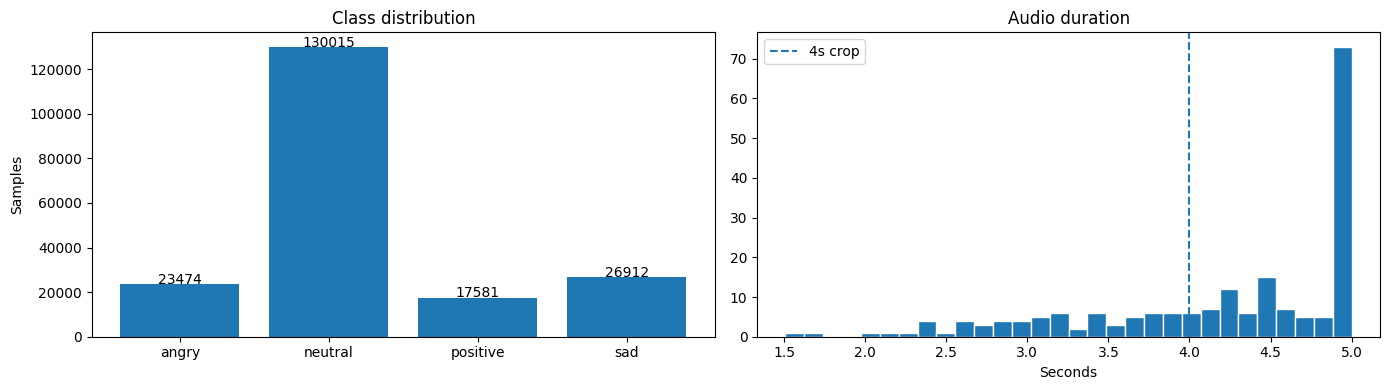

Duration: mean=4.21s, median=4.46s, max=5.00s


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = [label_counts.get(e, 0) for e in EMOTION_LABELS]
axes[0].bar(EMOTION_LABELS, counts)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Samples")
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha="center")

durations = []
if local_sample_list:
    dur_idx = rng.choice(len(local_sample_list), min(200, len(local_sample_list)), replace=False)
    for i in dur_idx:
        try:
            arr, sr = librosa.load(
                local_sample_list[i]["audio_path"], sr=None, mono=True,
                duration=MAX_AUDIO_LENGTH + 1
            )
            durations.append(len(arr) / sr)
        except Exception:
            pass

if durations:
    axes[1].hist(durations, bins=30, edgecolor="white")
    axes[1].axvline(MAX_AUDIO_LENGTH, linestyle="--", label=f"{MAX_AUDIO_LENGTH}s crop")
    axes[1].set_title("Audio duration")
    axes[1].set_xlabel("Seconds")
    axes[1].legend()
    dur_msg = f"Duration: mean={np.mean(durations):.2f}s, median={np.median(durations):.2f}s, max={np.max(durations):.2f}s"
else:
    axes[1].text(0.5, 0.5, "No audio loaded", ha="center", va="center", transform=axes[1].transAxes)
    dur_msg = "Duration stats unavailable."

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(dur_msg)


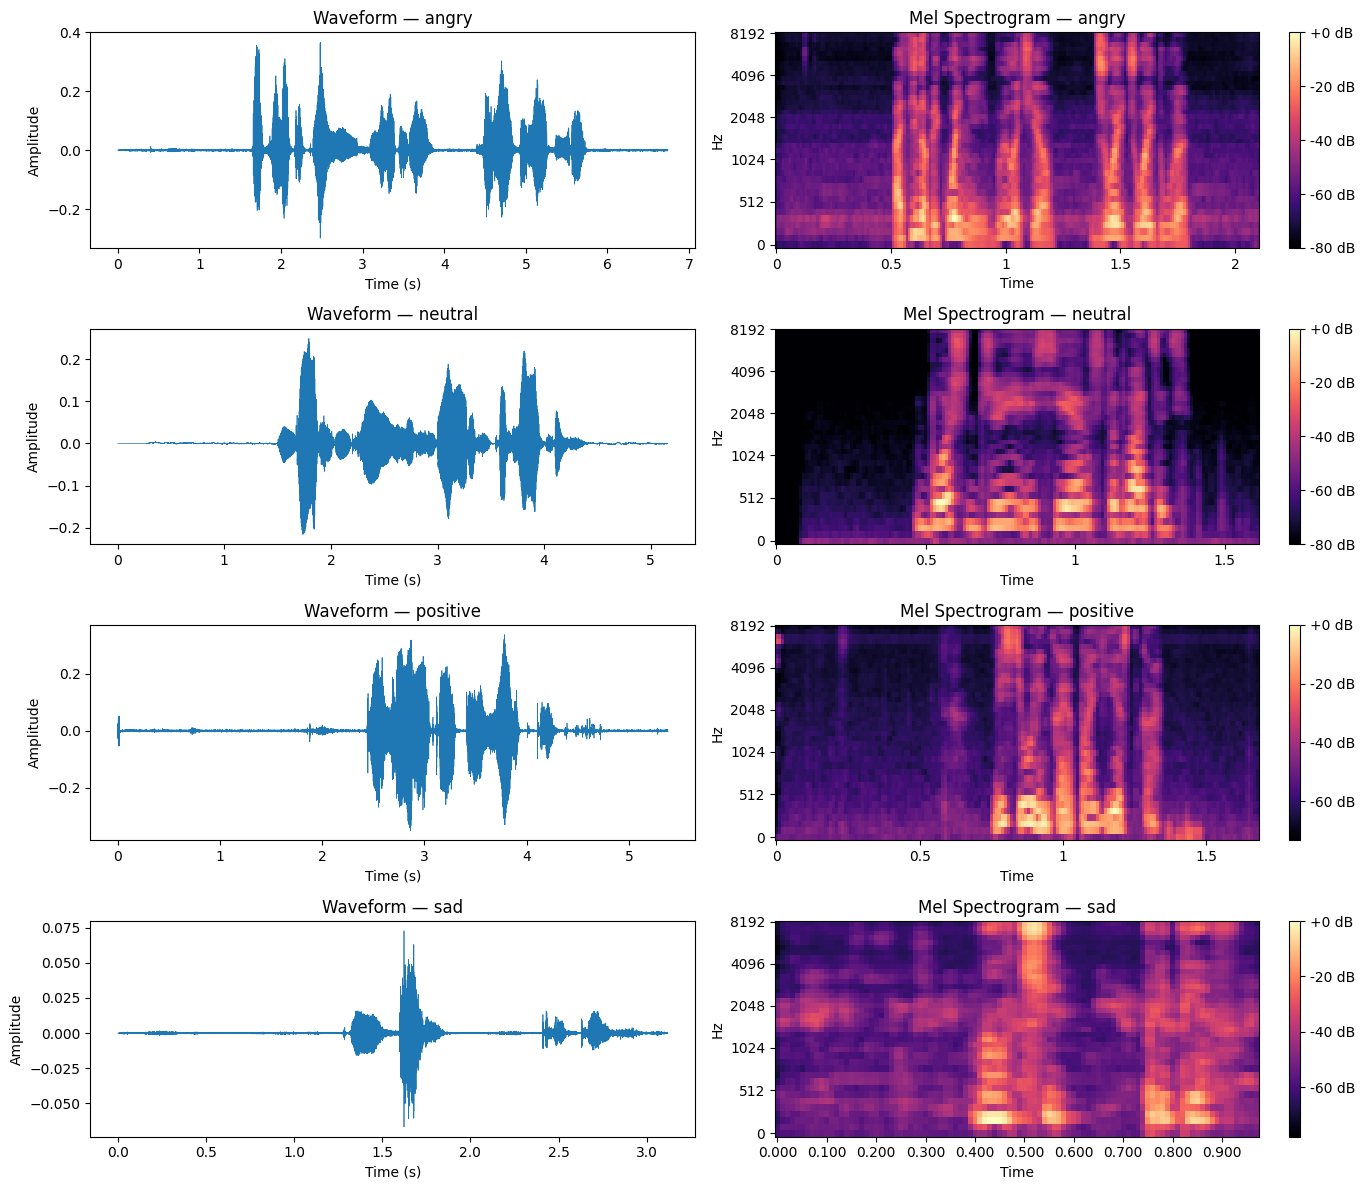

In [9]:
fig, axes = plt.subplots(len(EMOTION_LABELS), 2, figsize=(14, 3 * len(EMOTION_LABELS)))

for row, emotion in enumerate(EMOTION_LABELS):
    sample = next((s for s in local_sample_list if s['label'] == emotion), None)
    if sample is None:
        continue

    arr, sr = librosa.load(sample['audio_path'], sr=AUDIO_SAMPLE_RATE, mono=True)

    time_axis = np.linspace(0, len(arr) / sr, len(arr))
    axes[row, 0].plot(time_axis, arr, linewidth=0.5)
    axes[row, 0].set_title(f"Waveform — {emotion}")
    axes[row, 0].set_xlabel("Time (s)")
    axes[row, 0].set_ylabel("Amplitude")

    S    = librosa.feature.melspectrogram(y=arr, sr=sr, n_mels=MFCC_N_MELS)
    S_db = librosa.power_to_db(S, ref=np.max)
    img  = librosa.display.specshow(S_db, sr=sr, hop_length=MFCC_HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=axes[row, 1])
    axes[row, 1].set_title(f"Mel Spectrogram — {emotion}")
    fig.colorbar(img, ax=axes[row, 1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_waveforms_spectrograms.png", dpi=150, bbox_inches='tight')
plt.show()


---
## Step 2 — Preprocessing & Feature Extraction


In [10]:
labels_all = [s['label'] for s in local_sample_list]

train_val_list, test_list = sk_split(
    local_sample_list, test_size=TEST_RATIO,
    stratify=labels_all, random_state=RANDOM_SEED
)

val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_list, val_list = sk_split(
    train_val_list, test_size=val_frac,
    stratify=[s['label'] for s in train_val_list], random_state=RANDOM_SEED
)

print(f"Train: {len(train_list)}  Val: {len(val_list)}  Test: {len(test_list)}")
print(f"Train label distribution: {dict(Counter(s['label'] for s in train_list))}")


Train: 138586  Val: 29698  Test: 29698
Train label distribution: {'neutral': 91009, 'angry': 16432, 'sad': 18838, 'positive': 12307}


In [11]:
def _read_wav(path):
    try:
        data, sr = sf.read(path, dtype="float32", always_2d=False)
        if data.ndim == 2:
            data = data.mean(axis=1)
        if sr != AUDIO_SAMPLE_RATE:
            data = librosa.resample(data, orig_sr=sr, target_sr=AUDIO_SAMPLE_RATE)
    except Exception:
        data, _ = librosa.load(path, sr=AUDIO_SAMPLE_RATE, mono=True)
    return data.astype(np.float32)


def _mfcc_static(wav):
    return librosa.feature.mfcc(
        y=wav,
        sr=AUDIO_SAMPLE_RATE,
        n_mfcc=MFCC_N_MFCC,
        n_mels=MFCC_N_MELS,
        hop_length=MFCC_HOP_LENGTH,
    ).T.astype(np.float32)


def _apply_scaler_chunked(cache, scaler, chunk=8000):
    n, t, f = cache.shape
    for i in range(0, n, chunk):
        sl = cache[i:i + chunk]
        cache[i:i + chunk] = scaler.transform(
            sl.reshape(-1, f).astype(np.float32)
        ).reshape(-1, t, f).astype(np.float16)


class DushaDataset(Dataset):
    def __init__(
        self,
        data_list,
        feature_type="mfcc",
        augment=False,
        mfcc_scaler=None,
        num_workers=4,
        max_audio_length=None,
    ):
        self.feature_type = feature_type
        self.augment = augment
        self.mfcc_scaler = mfcc_scaler
        self.labels = np.array([LABEL_TO_ID[s["label"]] for s in data_list], dtype=np.int64)
        self.emotions = [s["label"] for s in data_list]
        self._paths = [s["audio_path"] for s in data_list]
        self.max_audio_length = max_audio_length or MAX_AUDIO_LENGTH
        self.max_frames = int(self.max_audio_length * AUDIO_SAMPLE_RATE / MFCC_HOP_LENGTH)
        self.max_samp = int(self.max_audio_length * AUDIO_SAMPLE_RATE)
        self._cache = None

        if feature_type == "mfcc" and CACHE_MFCC_IN_RAM:
            print(f"Caching MFCC: {len(self._paths)} samples, {self.max_audio_length}s")
            self._cache = self._build_mfcc_cache(self._paths, num_workers=num_workers)
            if self.mfcc_scaler is not None:
                _apply_scaler_chunked(self._cache, self.mfcc_scaler)
            print(f"MFCC cache: {self._cache.shape}, {self._cache.nbytes / 1024**2:.0f} MB")
        elif feature_type == "mfcc":
            print(f"MFCC dataset: {len(self._paths)} samples (lazy)")
        else:
            print(f"Waveform dataset: {len(self._paths)} samples, {self.max_audio_length}s")

    def _build_mfcc_cache(self, paths, num_workers=4):
        cache = np.zeros((len(paths), self.max_frames, MFCC_FEATURE_DIM), dtype=np.float16)

        def read_one(item):
            i, path = item
            try:
                feat = _mfcc_static(_read_wav(path))[:self.max_frames]
                t = min(len(feat), self.max_frames)
                if t:
                    cache[i, :t] = feat[:t].astype(np.float16)
            except Exception:
                pass

        workers = max(1, min(num_workers, os.cpu_count() or 1))
        with ThreadPoolExecutor(max_workers=workers) as ex:
            list(tqdm(ex.map(read_one, enumerate(paths)), total=len(paths), desc="mfcc", leave=False))
        return cache

    def _load_mfcc_lazy(self, idx):
        try:
            feat = _mfcc_static(_read_wav(self._paths[idx]))[:self.max_frames]
            if self.mfcc_scaler is not None and len(feat):
                feat = self.mfcc_scaler.transform(feat.astype(np.float32)).astype(np.float32)
        except Exception:
            feat = np.zeros((0, MFCC_FEATURE_DIM), dtype=np.float32)
        out = np.zeros((self.max_frames, MFCC_FEATURE_DIM), dtype=np.float32)
        t = min(len(feat), self.max_frames)
        if t:
            out[:t] = feat[:t]
        return out

    def _augment_mfcc(self, x):
        x = x.copy()
        t, f = x.shape
        if np.random.rand() < 0.5:
            width = np.random.randint(SPEC_AUGMENT_FREQ_MASK[0], SPEC_AUGMENT_FREQ_MASK[1] + 1)
            if 0 < width < f:
                start = np.random.randint(0, f - width + 1)
                x[:, start:start + width] = 0
        if np.random.rand() < 0.5:
            width = np.random.randint(SPEC_AUGMENT_TIME_MASK[0], SPEC_AUGMENT_TIME_MASK[1] + 1)
            if 0 < width < t:
                start = np.random.randint(0, t - width + 1)
                x[start:start + width] = 0
        return x

    def _augment_waveform(self, wav):
        wav = wav.copy()
        if np.random.rand() < 0.5:
            wav *= np.random.uniform(0.85, 1.15)
        if np.random.rand() < 0.25:
            wav += np.random.normal(0, 0.003, size=wav.shape).astype(np.float32)
        return np.clip(wav, -1.0, 1.0)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label_id = int(self.labels[idx])

        if self.feature_type == "mfcc":
            if self._cache is not None:
                feat = self._cache[idx].astype(np.float32)
            else:
                feat = self._load_mfcc_lazy(idx)
            if self.augment:
                feat = self._augment_mfcc(feat)
            return {
                "feature": torch.from_numpy(feat),
                "label": torch.tensor(label_id, dtype=torch.long),
                "emotion": self.emotions[idx],
            }

        try:
            wav = _read_wav(self._paths[idx])
        except Exception:
            wav = np.zeros(1, dtype=np.float32)

        if self.augment:
            wav = self._augment_waveform(wav)

        out = np.zeros(self.max_samp, dtype=np.float32)
        mask = np.zeros(self.max_samp, dtype=np.int64)
        t = min(len(wav), self.max_samp)
        out[:t] = wav[:t]
        mask[:t] = 1

        return {
            "feature": torch.from_numpy(out),
            "attention_mask": torch.from_numpy(mask),
            "label": torch.tensor(label_id, dtype=torch.long),
            "emotion": self.emotions[idx],
        }

In [12]:
def stratified_subset(data_list, max_items, seed=RANDOM_SEED):
    if max_items is None or max_items <= 0 or len(data_list) <= max_items:
        return data_list
    labels = np.array([s["label"] for s in data_list])
    selected = []
    rng = np.random.default_rng(seed)
    per_class = max(1, max_items // len(EMOTION_LABELS))
    for label in EMOTION_LABELS:
        idx = np.where(labels == label)[0]
        take = min(len(idx), per_class)
        selected.extend(rng.choice(idx, size=take, replace=False).tolist())
    if len(selected) < max_items:
        rest = np.setdiff1d(np.arange(len(data_list)), np.array(selected), assume_unique=False)
        take = min(len(rest), max_items - len(selected))
        if take > 0:
            selected.extend(rng.choice(rest, size=take, replace=False).tolist())
    selected = sorted(selected)
    return [data_list[i] for i in selected]


def make_dataloaders(train_list, val_list, test_list, feature_type="mfcc", batch_size=64, mfcc_scaler=None):
    if feature_type == "mfcc":
        if CACHE_MFCC_IN_RAM:
            train_ds = DushaDataset(
                train_list, "mfcc", augment=False,
                num_workers=DATALOADER_WORKERS_BASELINE,
                max_audio_length=MAX_AUDIO_LENGTH,
            )
            n, t, f = train_ds._cache.shape
            mfcc_scaler = StandardScaler()
            for i in range(0, n, 8000):
                mfcc_scaler.partial_fit(train_ds._cache[i:i + 8000].reshape(-1, f).astype(np.float32))
            _apply_scaler_chunked(train_ds._cache, mfcc_scaler)
            train_ds.augment = True
            val_ds = DushaDataset(
                val_list, "mfcc", augment=False, mfcc_scaler=mfcc_scaler,
                num_workers=DATALOADER_WORKERS_BASELINE,
                max_audio_length=MAX_AUDIO_LENGTH,
            )
            test_ds = DushaDataset(
                test_list, "mfcc", augment=False, mfcc_scaler=mfcc_scaler,
                num_workers=DATALOADER_WORKERS_BASELINE,
                max_audio_length=MAX_AUDIO_LENGTH,
            )
        else:
            if mfcc_scaler is None:
                mfcc_scaler = StandardScaler()
                sample = train_list[:min(3000, len(train_list))]
                tmp_frames = int(MAX_AUDIO_LENGTH * AUDIO_SAMPLE_RATE / MFCC_HOP_LENGTH)
                for s in tqdm(sample, desc="scaler", leave=False):
                    try:
                        feat = _mfcc_static(_read_wav(s["audio_path"]))[:tmp_frames]
                        if len(feat):
                            mfcc_scaler.partial_fit(feat.astype(np.float32))
                    except Exception:
                        pass
            train_ds = DushaDataset(train_list, "mfcc", augment=True, mfcc_scaler=mfcc_scaler, max_audio_length=MAX_AUDIO_LENGTH)
            val_ds = DushaDataset(val_list, "mfcc", augment=False, mfcc_scaler=mfcc_scaler, max_audio_length=MAX_AUDIO_LENGTH)
            test_ds = DushaDataset(test_list, "mfcc", augment=False, mfcc_scaler=mfcc_scaler, max_audio_length=MAX_AUDIO_LENGTH)
        workers = DATALOADER_WORKERS_BASELINE
    else:
        train_ds = DushaDataset(train_list, "waveform", augment=True, max_audio_length=TRANSFORMER_MAX_AUDIO_LENGTH)
        val_ds = DushaDataset(val_list, "waveform", augment=False, max_audio_length=TRANSFORMER_MAX_AUDIO_LENGTH)
        test_ds = DushaDataset(test_list, "waveform", augment=False, max_audio_length=TRANSFORMER_MAX_AUDIO_LENGTH)
        workers = DATALOADER_WORKERS_TRANSFORMER

    train_ids = np.array([LABEL_TO_ID[s["label"]] for s in train_list])
    counts = np.bincount(train_ids, minlength=NUM_EMOTIONS).astype(float)
    weights = len(train_ids) / (NUM_EMOTIONS * np.maximum(counts, 1.0))
    class_wts = torch.tensor(weights, dtype=torch.float32)

    sampler = None
    shuffle = True
    if USE_WEIGHTED_SAMPLER:
        sample_weights = weights[train_ids]
        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )
        shuffle = False

    nw = min(workers, os.cpu_count() or 1)
    dl_kw = dict(
        batch_size=batch_size,
        pin_memory=(DEVICE.type == "cuda"),
        num_workers=nw,
        persistent_workers=(nw > 0),
    )
    if nw > 0:
        dl_kw["prefetch_factor"] = 2

    train_loader = DataLoader(train_ds, shuffle=shuffle, sampler=sampler, **dl_kw)
    val_loader = DataLoader(val_ds, shuffle=False, **dl_kw)
    test_loader = DataLoader(test_ds, shuffle=False, **dl_kw)

    print(f"{feature_type}: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")
    print(f"class weights: {np.round(weights, 3)}")
    return train_loader, val_loader, test_loader, class_wts, mfcc_scaler

---
## Step 3 — Baseline Model (CNN / LSTM on MFCC)


In [13]:
class BaselineCNN(nn.Module):
    def __init__(self, n_features=MFCC_FEATURE_DIM, num_classes=NUM_EMOTIONS):
        super().__init__()
        layers = []
        in_ch = n_features
        for out_ch, ks in zip(CNN_CHANNELS, CNN_KERNEL_SIZES):
            layers += [
                nn.Conv1d(in_ch, out_ch, ks, padding=ks // 2),
                nn.BatchNorm1d(out_ch),
                nn.GELU(),
                nn.MaxPool1d(2),
                nn.Dropout(DROPOUT_RATE),
            ]
            in_ch = out_ch

        self.encoder = nn.Sequential(*layers)
        self.attn = nn.Sequential(
            nn.Conv1d(in_ch, 1, kernel_size=1),
            nn.Softmax(dim=-1),
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(in_ch * 2),
            nn.Linear(in_ch * 2, 256),
            nn.GELU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.encoder(x.transpose(1, 2))
        mean_pool = x.mean(dim=-1)
        attn_pool = (x * self.attn(x)).sum(dim=-1)
        return self.classifier(torch.cat([mean_pool, attn_pool], dim=1))


class BaselineLSTM(nn.Module):
    def __init__(self, input_size=MFCC_FEATURE_DIM, hidden_dim=LSTM_HIDDEN_DIM, num_classes=NUM_EMOTIONS):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=DROPOUT_RATE,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim * 4),
            nn.Linear(hidden_dim * 4, 256),
            nn.GELU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        seq, _ = self.lstm(x)
        mean_pool = seq.mean(dim=1)
        max_pool = seq.max(dim=1).values
        return self.classifier(torch.cat([mean_pool, max_pool], dim=1))


def create_baseline_model(model_type=BASELINE_MODEL):
    model_type = model_type.lower()
    if model_type == "cnn":
        return BaselineCNN(n_features=MFCC_FEATURE_DIM, num_classes=NUM_EMOTIONS)
    if model_type == "lstm":
        return BaselineLSTM(input_size=MFCC_FEATURE_DIM, num_classes=NUM_EMOTIONS)
    raise ValueError(f"Unknown model type: {model_type}")


_m = create_baseline_model("cnn")
_max_frames = int(MAX_AUDIO_LENGTH * AUDIO_SAMPLE_RATE / MFCC_HOP_LENGTH)
_x = torch.randn(4, _max_frames, MFCC_FEATURE_DIM)
print(f"CNN output: {_m(_x).shape}; params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x, _max_frames


CNN output: torch.Size([4, 4]); params: 44,309


In [14]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_LOSS_GAMMA, class_weights=None):
        super().__init__()
        self.gamma         = gamma
        self.class_weights = class_weights

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.class_weights, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def get_loss_fn(use_focal=USE_FOCAL_LOSS, class_weights=None):
    wts = class_weights.to(DEVICE) if class_weights is not None else None
    if use_focal:
        return FocalLoss(gamma=FOCAL_LOSS_GAMMA, class_weights=wts)
    return nn.CrossEntropyLoss(weight=wts)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    m = {
        "accuracy":    accuracy_score(y_true, y_pred),
        "macro_f1":    f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision":   precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":      recall_score(y_true, y_pred, average="macro",    zero_division=0),
    }
    f1s  = f1_score(y_true, y_pred, average=None, zero_division=0)
    prec = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec  = recall_score(y_true, y_pred, average=None, zero_division=0)
    for i, lbl in enumerate(EMOTION_LABELS):
        m[f"f1_{lbl}"]        = f1s[i]  if i < len(f1s)  else 0.0
        m[f"precision_{lbl}"] = prec[i] if i < len(prec) else 0.0
        m[f"recall_{lbl}"]    = rec[i]  if i < len(rec)  else 0.0
    return m


def print_metrics(metrics, label=""):
    if label:
        print(f"\n{'='*50}\n{label}\n{'='*50}")
    print(f"Accuracy    : {metrics['accuracy']:.4f}")
    print(f"Macro F1    : {metrics['macro_f1']:.4f}  <- primary metric")
    print(f"Weighted F1 : {metrics['weighted_f1']:.4f}")
    print(f"Precision   : {metrics['precision']:.4f}")
    print(f"Recall      : {metrics['recall']:.4f}")
    print("\nPer-class:")
    for lbl in EMOTION_LABELS:
        print(f"  {lbl:10s}: "
              f"F1={metrics.get(f'f1_{lbl}', 0):.4f}  "
              f"P={metrics.get(f'precision_{lbl}', 0):.4f}  "
              f"R={metrics.get(f'recall_{lbl}', 0):.4f}")


In [15]:
def _available_gb(path="/kaggle/working"):
    try:
        import shutil
        return shutil.disk_usage(path).free / 1024**3
    except Exception:
        return float("nan")


def safe_save_state_dict(state_dict, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp_path = path + ".tmp"
    try:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)
        torch.save(state_dict, tmp_path, _use_new_zipfile_serialization=False)
        os.replace(tmp_path, path)
        return True
    except Exception as exc:
        try:
            if os.path.exists(tmp_path):
                os.remove(tmp_path)
        except Exception:
            pass
        print(f"checkpoint was not written ({exc}). Continuing with the best weights kept in memory.")
        print(f"free disk space: {_available_gb():.2f} GB")
        return False

class Trainer:
    def __init__(self, model, model_name="model"):
        if USE_DATA_PARALLEL and NUM_GPUS > 1:
            model = nn.DataParallel(model)
            print(f"[{model_name}] DataParallel on {NUM_GPUS} GPUs")

        self.model = model.to(DEVICE)
        self.model_name = model_name
        self.best_f1 = 0.0
        self.patience_ctr = 0
        self.history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
        self.best_state = None
        check_model_device(self.model, model_name)

    @property
    def _raw_model(self):
        return self.model.module if isinstance(self.model, nn.DataParallel) else self.model

    def _forward_batch(self, batch):
        features = batch["feature"].to(DEVICE, non_blocking=True)
        if "attention_mask" in batch:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            return self.model(features, attention_mask=mask)
        return self.model(features)

    def _train_epoch(self, loader, optimizer, loss_fn, scaler, grad_accumulation_steps):
        self.model.train()
        optimizer.zero_grad(set_to_none=True)
        total_loss, all_preds, all_labels = 0.0, [], []
        amp_ctx = torch.amp.autocast("cuda") if scaler else contextlib.nullcontext()

        for step, batch in enumerate(tqdm(loader, desc="train", leave=False)):
            labels = batch["label"].to(DEVICE, non_blocking=True)

            with amp_ctx:
                logits = self._forward_batch(batch)
                loss = loss_fn(logits, labels) / grad_accumulation_steps

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            do_step = (step + 1) % grad_accumulation_steps == 0 or (step + 1) == len(loader)
            if do_step:
                if scaler:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            total_loss += loss.item() * grad_accumulation_steps
            all_preds.extend(logits.argmax(1).detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

        metrics = compute_metrics(all_labels, all_preds)
        metrics["loss"] = total_loss / max(1, len(loader))
        return metrics

    def _validate(self, loader, loss_fn):
        self.model.eval()
        total_loss, all_preds, all_labels = 0.0, [], []
        with torch.no_grad():
            for batch in tqdm(loader, desc="val", leave=False):
                labels = batch["label"].to(DEVICE, non_blocking=True)
                logits = self._forward_batch(batch)
                total_loss += loss_fn(logits, labels).item()
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        metrics = compute_metrics(all_labels, all_preds)
        metrics["loss"] = total_loss / max(1, len(loader))
        return metrics

    def fit(self, train_loader, val_loader, lr=BASELINE_LR, num_epochs=NUM_EPOCHS, class_weights=None, grad_accumulation_steps=1):
        loss_weights = class_weights if USE_CLASS_WEIGHTS else None
        loss_fn = get_loss_fn(use_focal=USE_FOCAL_LOSS, class_weights=loss_weights)
        params = [p for p in self.model.parameters() if p.requires_grad]
        optimizer = optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)

        if LR_SCHEDULER == "cosine":
            scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
        elif LR_SCHEDULER == "linear":
            scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=num_epochs)
        else:
            scheduler = None

        scaler = torch.amp.GradScaler("cuda") if USE_MIXED_PRECISION and DEVICE.type == "cuda" else None
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_VERSION}_{self.model_name}_best.pt")

        print(f"Training {self.model_name}: epochs={num_epochs}, lr={lr:g}, grad_acc={grad_accumulation_steps}")
        print(f"[{self.model_name}] GPU training: {DEVICE.type == 'cuda'}")

        for epoch in range(num_epochs):
            tr = self._train_epoch(train_loader, optimizer, loss_fn, scaler, grad_accumulation_steps)
            vl = self._validate(val_loader, loss_fn)

            if scheduler:
                scheduler.step()

            self.history["train_loss"].append(tr["loss"])
            self.history["val_loss"].append(vl["loss"])
            self.history["train_f1"].append(tr["macro_f1"])
            self.history["val_f1"].append(vl["macro_f1"])

            saved = ""
            if vl["macro_f1"] > self.best_f1:
                self.best_f1 = vl["macro_f1"]
                self.patience_ctr = 0
                state = {k: v.detach().cpu().clone() for k, v in self._raw_model.state_dict().items()}
                self.best_state = state
                if safe_save_state_dict(state, ckpt_path):
                    saved = " *"
                else:
                    saved = " * (memory only)"
            else:
                self.patience_ctr += 1

            print(
                f"Ep {epoch + 1:02d}/{num_epochs} "
                f"train_loss={tr['loss']:.4f} train_f1={tr['macro_f1']:.4f} "
                f"val_loss={vl['loss']:.4f} val_f1={vl['macro_f1']:.4f}{saved}"
            )

            if self.patience_ctr >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch + 1}.")
                break

        if os.path.exists(ckpt_path):
            self._raw_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
            print(f"Restored best val_f1={self.best_f1:.4f}")
        elif self.best_state is not None:
            self._raw_model.load_state_dict(self.best_state)
            print(f"Restored best val_f1={self.best_f1:.4f} from memory")

        check_model_device(self.model, self.model_name)
        return self.model

    def plot_history(self, save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(self.history["train_loss"], label="train")
        ax1.plot(self.history["val_loss"], label="val")
        ax1.set_title(f"{self.model_name}: loss")
        ax1.legend()
        ax2.plot(self.history["train_f1"], label="train")
        ax2.plot(self.history["val_f1"], label="val")
        ax2.set_title(f"{self.model_name}: macro F1")
        ax2.legend()
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

In [16]:
"""BASELINE_CKPT = os.path.join(CHECKPOINT_DIR, f"{MODEL_VERSION}_baseline_{BASELINE_MODEL}_best.pt")
SCALER_PATH = os.path.join(CHECKPOINT_DIR, f"{MODEL_VERSION}_mfcc_scaler.pkl")

ckpt_ready = False
if os.path.exists(BASELINE_CKPT) and os.path.exists(SCALER_PATH):
    try:
        with open(SCALER_PATH, "rb") as f:
            mfcc_scaler = pickle.load(f)
        ckpt_ready = True
    except Exception as exc:
        print(f"Could not load saved scaler: {exc}")

if ckpt_ready:
    print("Found baseline checkpoint; loading it.")
    test_ds_mfcc = DushaDataset(test_list, "mfcc", augment=False, mfcc_scaler=mfcc_scaler, num_workers=DATALOADER_WORKERS_BASELINE)
    nw = min(DATALOADER_WORKERS_BASELINE, os.cpu_count() or 1)
    test_loader_mfcc = DataLoader(
        test_ds_mfcc,
        batch_size=BASELINE_BATCH_SIZE,
        shuffle=False,
        pin_memory=(DEVICE.type == "cuda"),
        num_workers=nw,
        persistent_workers=(nw > 0),
    )
    train_loader_mfcc = None
    val_loader_mfcc = None

    baseline_model = create_baseline_model(BASELINE_MODEL)
    baseline_model.load_state_dict(torch.load(BASELINE_CKPT, map_location=DEVICE, weights_only=True))
    baseline_model = baseline_model.to(DEVICE)
    if USE_DATA_PARALLEL and NUM_GPUS > 1:
        baseline_model = nn.DataParallel(baseline_model)
    check_model_device(baseline_model, f"baseline_{BASELINE_MODEL}")
    baseline_trainer = None
else:
    train_loader_mfcc, val_loader_mfcc, test_loader_mfcc, class_wts, mfcc_scaler = make_dataloaders(
        train_list,
        val_list,
        test_list,
        feature_type="mfcc",
        batch_size=BASELINE_BATCH_SIZE,
    )

    with open(SCALER_PATH, "wb") as f:
        pickle.dump(mfcc_scaler, f)

    baseline_model = create_baseline_model(BASELINE_MODEL)
    print(f"Baseline params: {sum(p.numel() for p in baseline_model.parameters()):,}")

    baseline_trainer = Trainer(baseline_model, model_name=f"baseline_{BASELINE_MODEL}")
    baseline_model = baseline_trainer.fit(
        train_loader_mfcc,
        val_loader_mfcc,
        lr=BASELINE_LR,
        num_epochs=NUM_EPOCHS,
        class_weights=class_wts,
        grad_accumulation_steps=BASELINE_GRADIENT_ACCUMULATION_STEPS,
    )
    baseline_trainer.plot_history(save_path=f"{RESULTS_DIR}/training_history_baseline.png")"""

'BASELINE_CKPT = os.path.join(CHECKPOINT_DIR, f"{MODEL_VERSION}_baseline_{BASELINE_MODEL}_best.pt")\nSCALER_PATH = os.path.join(CHECKPOINT_DIR, f"{MODEL_VERSION}_mfcc_scaler.pkl")\n\nckpt_ready = False\nif os.path.exists(BASELINE_CKPT) and os.path.exists(SCALER_PATH):\n    try:\n        with open(SCALER_PATH, "rb") as f:\n            mfcc_scaler = pickle.load(f)\n        ckpt_ready = True\n    except Exception as exc:\n        print(f"Could not load saved scaler: {exc}")\n\nif ckpt_ready:\n    print("Found baseline checkpoint; loading it.")\n    test_ds_mfcc = DushaDataset(test_list, "mfcc", augment=False, mfcc_scaler=mfcc_scaler, num_workers=DATALOADER_WORKERS_BASELINE)\n    nw = min(DATALOADER_WORKERS_BASELINE, os.cpu_count() or 1)\n    test_loader_mfcc = DataLoader(\n        test_ds_mfcc,\n        batch_size=BASELINE_BATCH_SIZE,\n        shuffle=False,\n        pin_memory=(DEVICE.type == "cuda"),\n        num_workers=nw,\n        persistent_workers=(nw > 0),\n    )\n    train_loader

---
## Step 4 — Fine-Tuning a Pretrained Transformer (WavLM)


In [17]:
class TransformerSERModel(nn.Module):
    def __init__(self, model_name=TRANSFORMER_MODEL, num_classes=NUM_EMOTIONS):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)

        for p in self.backbone.feature_extractor.parameters():
            p.requires_grad = False

        for i, layer in enumerate(self.backbone.encoder.layers):
            if i < NUM_FROZEN_TRANSFORMER_LAYERS:
                for p in layer.parameters():
                    p.requires_grad = False

        hidden = self.config.hidden_size
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Linear(hidden * 2, 256),
            nn.GELU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(256, num_classes),
        )

    def _masked_stats_pool(self, hidden, attention_mask):
        if attention_mask is None:
            return torch.cat([hidden.mean(dim=1), hidden.max(dim=1).values], dim=1)

        mask = attention_mask
        if mask.size(1) != hidden.size(1):
            mask = F.interpolate(
                mask.float().unsqueeze(1),
                size=hidden.size(1),
                mode="nearest"
            ).squeeze(1)

        mask = mask.to(hidden.device).unsqueeze(-1).float()
        denom = mask.sum(dim=1).clamp_min(1.0)
        mean_pool = (hidden * mask).sum(dim=1) / denom

        masked_hidden = hidden.masked_fill(mask == 0, -1e4)
        max_pool = masked_hidden.max(dim=1).values
        return torch.cat([mean_pool, max_pool], dim=1)

    def forward(self, input_values, attention_mask=None):
        out = self.backbone(
            input_values=input_values,
            attention_mask=attention_mask,
            return_dict=True,
        )
        pooled = self._masked_stats_pool(out.last_hidden_state, attention_mask)
        return self.classifier(pooled)


def create_transformer_model(model_name=TRANSFORMER_MODEL):
    model = TransformerSERModel(model_name=model_name)
    total_p = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = NUM_FROZEN_TRANSFORMER_LAYERS
    total_layers = model.config.num_hidden_layers
    print(f"Encoder layers: {total_layers - frozen} trainable, {frozen} frozen")
    print(f"Params: {trainable_p:,} trainable / {total_p:,} total")
    return model


In [22]:
for name in ["train_loader_mfcc", "val_loader_mfcc"]:
    if name in globals():
        del globals()[name]

import gc
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

try:
    import ctypes
    ctypes.CDLL("libc.so.6").malloc_trim(0)
except Exception:
    pass

val_list_wav = stratified_subset(val_list, TRANSFORMER_VAL_SUBSET, seed=RANDOM_SEED)
print(f"Transformer validation uses {len(val_list_wav)} / {len(val_list)} samples per epoch.")
print("Full test set is kept for final evaluation.")

print("Building waveform dataloaders...")
train_loader_wav, val_loader_wav, test_loader_wav, class_wts_wav, _ = make_dataloaders(
    train_list,
    val_list_wav,
    test_list,
    feature_type="waveform",
    batch_size=TRANSFORMER_BATCH_SIZE,
)

print(f"Loading {TRANSFORMER_MODEL}...")
transformer_model = create_transformer_model()

weights_path = "/kaggle/input/datasets/mechanismman/epoch-5/v8_final_stable_transformer_wavlm_best.pt"

state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)
transformer_model.load_state_dict(state_dict)

transformer_model = transformer_model.to(DEVICE)

"""transformer_trainer = Trainer(transformer_model, model_name="transformer_wavlm")
transformer_model = transformer_trainer.fit(
    train_loader_wav,
    val_loader_wav,
    lr=TRANSFORMER_LR,
    num_epochs=TRANSFORMER_NUM_EPOCHS,
    class_weights=class_wts_wav,
    grad_accumulation_steps=TRANSFORMER_GRADIENT_ACCUMULATION_STEPS,
)
transformer_trainer.plot_history(save_path=f"{RESULTS_DIR}/training_history_transformer.png")"""

"""total_epochs = TRANSFORMER_NUM_EPOCHS
epochs_done = 5
remaining_epochs = total_epochs - epochs_done 

transformer_trainer = Trainer(transformer_model, model_name="transformer_wavlm")

transformer_model = transformer_trainer.fit(
    train_loader_wav,
    val_loader_wav,
    lr=TRANSFORMER_LR * 0.5,
    num_epochs=remaining_epochs,
    class_weights=class_wts_wav,
    grad_accumulation_steps=TRANSFORMER_GRADIENT_ACCUMULATION_STEPS,
)
transformer_trainer.plot_history(save_path=f"{RESULTS_DIR}/training_history_transformer.png")"""

Transformer validation uses 5000 / 29698 samples per epoch.
Full test set is kept for final evaluation.
Building waveform dataloaders...
Waveform dataset: 138586 samples, 3s
Waveform dataset: 5000 samples, 3s
Waveform dataset: 29698 samples, 3s
waveform: train=138586, val=5000, test=29698
class weights: [2.108 0.381 2.815 1.839]
Loading microsoft/wavlm-base...


Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Encoder layers: 12 trainable, 0 frozen
Params: 90,579,060 trainable / 94,779,508 total


'total_epochs = TRANSFORMER_NUM_EPOCHS\nepochs_done = 5\nremaining_epochs = total_epochs - epochs_done \n\ntransformer_trainer = Trainer(transformer_model, model_name="transformer_wavlm")\n\ntransformer_model = transformer_trainer.fit(\n    train_loader_wav,\n    val_loader_wav,\n    lr=TRANSFORMER_LR * 0.5,\n    num_epochs=remaining_epochs,\n    class_weights=class_wts_wav,\n    grad_accumulation_steps=TRANSFORMER_GRADIENT_ACCUMULATION_STEPS,\n)\ntransformer_trainer.plot_history(save_path=f"{RESULTS_DIR}/training_history_transformer.png")'

---
## Step 5 — Evaluation & Error Analysis


In [19]:
def model_logits(model, batch):
    features = batch["feature"].to(DEVICE)
    if "attention_mask" in batch:
        return model(features, attention_mask=batch["attention_mask"].to(DEVICE))
    return model(features)


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="eval", leave=False):
            logits = model_logits(model, batch)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(batch["label"].numpy())

    preds = np.array(all_preds)
    labels = np.array(all_labels)
    return compute_metrics(labels, preds), preds, labels


def plot_confusion_matrix(y_true, y_pred, title="Confusion matrix", save_path=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_EMOTIONS)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, fmt, subtitle in [
        (axes[0], cm, "d", "counts"),
        (axes[1], cm_norm, ".2f", "normalised"),
    ]:
        sns.heatmap(
            data,
            annot=True,
            fmt=fmt,
            cmap="Blues",
            xticklabels=EMOTION_LABELS,
            yticklabels=EMOTION_LABELS,
            ax=ax,
            cbar=True,
        )
        ax.set_title(f"{title} ({subtitle})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_per_class_metrics(metrics, model_label="Model", save_path=None):
    f1s = [metrics.get(f"f1_{label}", 0) for label in EMOTION_LABELS]
    prec = [metrics.get(f"precision_{label}", 0) for label in EMOTION_LABELS]
    rec = [metrics.get(f"recall_{label}", 0) for label in EMOTION_LABELS]

    x = np.arange(len(EMOTION_LABELS))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, f1s, width, label="F1", alpha=0.85)
    ax.bar(x, prec, width, label="Precision", alpha=0.85)
    ax.bar(x + width, rec, width, label="Recall", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(EMOTION_LABELS)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{model_label}: per-class metrics")
    ax.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


In [20]:
print("\n" + "="*60)
print("BASELINE MODEL — TEST SET EVALUATION")
print("="*60)
baseline_metrics, baseline_preds, baseline_labels = evaluate_model(
    baseline_model, test_loader_mfcc
)
print_metrics(baseline_metrics, f"Baseline ({BASELINE_MODEL.upper()} on MFCC)")

plot_confusion_matrix(
    baseline_labels, baseline_preds,
    title=f"Baseline ({BASELINE_MODEL.upper()}) — Confusion Matrix",
    save_path=f"{RESULTS_DIR}/confusion_matrix_baseline.png"
)
plot_per_class_metrics(
    baseline_metrics,
    model_label=f"Baseline {BASELINE_MODEL.upper()}",
    save_path=f"{RESULTS_DIR}/per_class_baseline.png"
)



BASELINE MODEL — TEST SET EVALUATION


NameError: name 'baseline_model' is not defined


TRANSFORMER MODEL — TEST SET EVALUATION


eval:   0%|          | 0/1857 [00:00<?, ?it/s]


Transformer (WavLM)
Accuracy    : 0.7299
Macro F1    : 0.6809  <- primary metric
Weighted F1 : 0.7421
Precision   : 0.6498
Recall      : 0.7492

Per-class:
  angry     : F1=0.6789  P=0.5845  R=0.8097
  neutral   : F1=0.7954  P=0.9089  R=0.7070
  positive  : F1=0.6476  P=0.6269  R=0.6697
  sad       : F1=0.6019  P=0.4788  R=0.8103


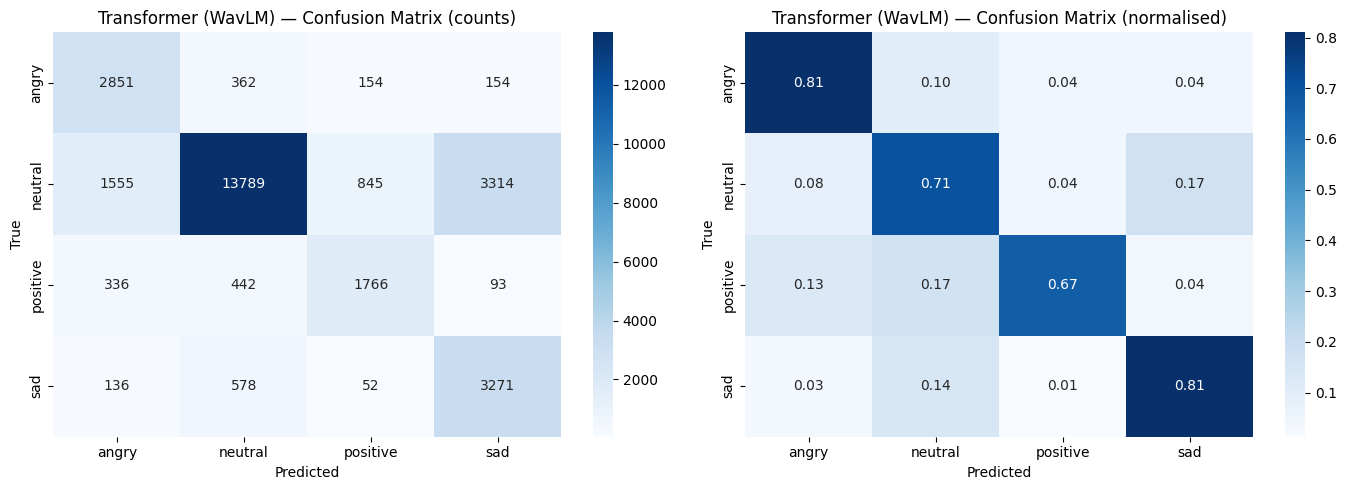

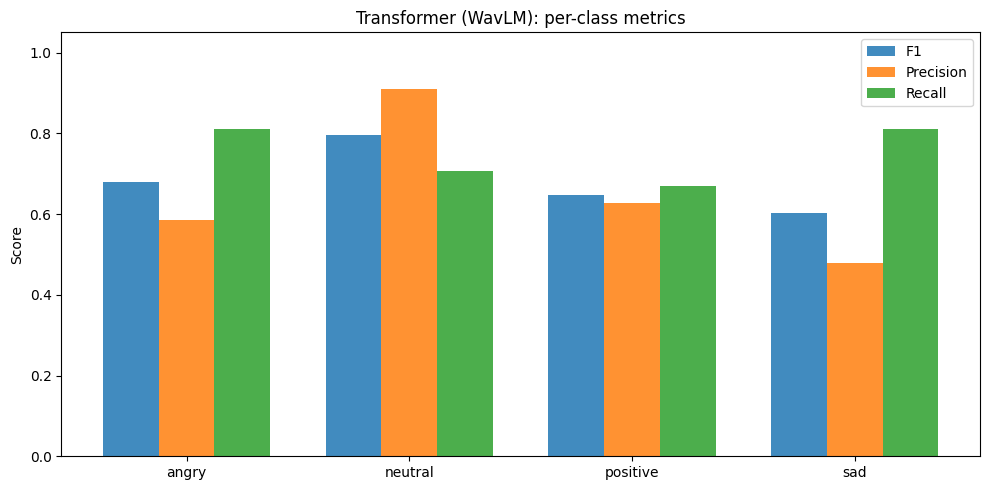

In [23]:
print("\n" + "="*60)
print("TRANSFORMER MODEL — TEST SET EVALUATION")
print("="*60)
transformer_metrics, transformer_preds, transformer_labels = evaluate_model(
    transformer_model, test_loader_wav
)
print_metrics(transformer_metrics, "Transformer (WavLM)")

plot_confusion_matrix(
    transformer_labels, transformer_preds,
    title="Transformer (WavLM) — Confusion Matrix",
    save_path=f"{RESULTS_DIR}/confusion_matrix_transformer.png"
)
plot_per_class_metrics(
    transformer_metrics,
    model_label="Transformer (WavLM)",
    save_path=f"{RESULTS_DIR}/per_class_transformer.png"
)


In [25]:
rows = []
metric_keys = ["accuracy", "macro_f1", "weighted_f1", "precision", "recall"] + [
    f"f1_{label}" for label in EMOTION_LABELS
]

for key in metric_keys:
    rows.append({
        "metric": key,
        "baseline": round(baseline_metrics.get(key, 0), 4),
        "transformer": round(transformer_metrics.get(key, 0), 4),
    })

df = pd.DataFrame(rows)
df["delta"] = (df["transformer"] - df["baseline"]).round(4)
df["winner"] = np.where(df["delta"] > 0, "transformer", np.where(df["delta"] < 0, "baseline", "tie"))

print(df.to_string(index=False))
df.to_csv(f"{RESULTS_DIR}/comparison_table.csv", index=False)

bf1 = baseline_metrics["macro_f1"]
tf1 = transformer_metrics["macro_f1"]
delta_pct = (tf1 - bf1) / (bf1 + 1e-9) * 100

print(f"\nMacro F1: baseline={bf1:.4f}, transformer={tf1:.4f}, delta={delta_pct:+.2f}%")
print(f"Winner: {'Transformer' if tf1 > bf1 else 'Baseline'}")


NameError: name 'baseline_metrics' is not defined

NameError: name 'baseline_labels' is not defined

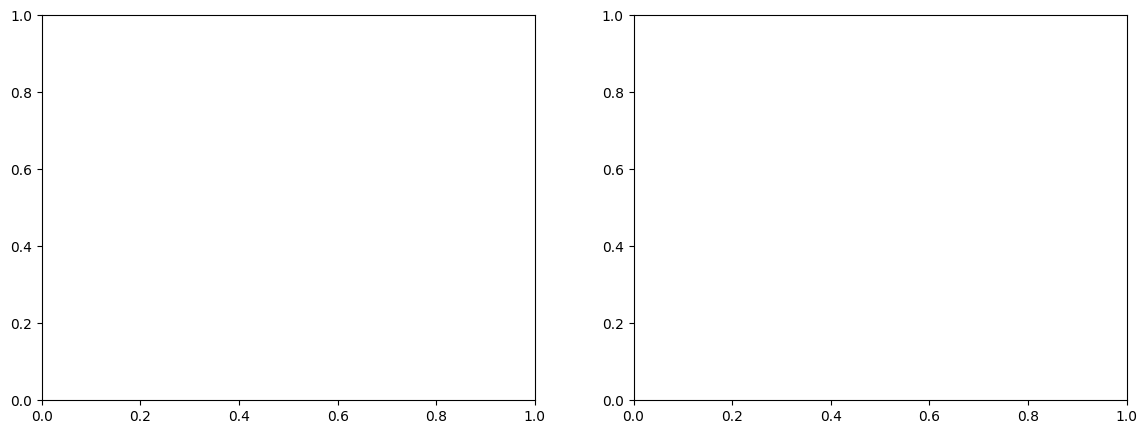

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

items = [
    (axes[0], baseline_labels, baseline_preds, f"Baseline ({BASELINE_MODEL.upper()})"),
    (axes[1], transformer_labels, transformer_preds, "Transformer (WavLM)"),
]

for ax, y_true, y_pred, title in items:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_EMOTIONS)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=EMOTION_LABELS,
        yticklabels=EMOTION_LABELS,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Normalised confusion matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/comparison_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


In [27]:
def top_misclassifications(y_true, y_pred, model_name, top_k=10):
    print(f"\n{model_name}: most frequent mistakes")
    pairs = Counter()

    for true_id, pred_id in zip(y_true, y_pred):
        if true_id != pred_id:
            pairs[(EMOTION_LABELS[true_id], EMOTION_LABELS[pred_id])] += 1

    for (true_label, pred_label), count in pairs.most_common(top_k):
        print(f"true={true_label:10s} pred={pred_label:10s} count={count}")


top_misclassifications(baseline_labels, baseline_preds, "Baseline")
top_misclassifications(transformer_labels, transformer_preds, "Transformer")


NameError: name 'baseline_labels' is not defined

In [29]:
bf1 = baseline_metrics['macro_f1']
tf1 = transformer_metrics['macro_f1']

lines = [
    "=" * 60,
    "DUSHA SER — RESULTS",
    "=" * 60,
    f"Dataset  : Dusha crowd ({SUBSET_PERCENT*100:.0f}%),  {len(baseline_labels)} test samples",
    f"Labels   : {EMOTION_LABELS}",
    "",
    f"Baseline  ({BASELINE_MODEL.upper()} on MFCC): macro F1 = {bf1:.4f}",
    f"Transformer (WavLM fine-tuned):  macro F1 = {tf1:.4f}",
    f"Delta: {tf1 - bf1:+.4f}  ({(tf1-bf1)/(bf1+1e-9)*100:+.2f}%)",
    "",
]
for key in ["accuracy", "weighted_f1", "precision", "recall"]:
    lines.append(f"  {key:15s}: baseline={baseline_metrics.get(key,0):.4f}  "
                 f"transformer={transformer_metrics.get(key,0):.4f}")
lines += ["", "Per-class F1:"]
for lbl in EMOTION_LABELS:
    lines.append(f"  {lbl:10s}: baseline={baseline_metrics.get(f'f1_{lbl}',0):.4f}  "
                 f"transformer={transformer_metrics.get(f'f1_{lbl}',0):.4f}")
lines.append("=" * 60)

report = "\n".join(lines)
print(report)
with open(f"{RESULTS_DIR}/report.txt", "w", encoding="utf-8") as f:
    f.write(report)


NameError: name 'baseline_metrics' is not defined

---
## Step 6 — Inference Demo


In [ ]:
def predict_emotion(model, audio_input, feature_type="mfcc", mfcc_scaler=None):
    if isinstance(audio_input, str):
        arr = _read_wav(audio_input)
    else:
        arr = np.asarray(audio_input, dtype=np.float32)

    model.eval()

    if feature_type == "mfcc":
        max_frames = int(MAX_AUDIO_LENGTH * AUDIO_SAMPLE_RATE / MFCC_HOP_LENGTH)
        mfcc = _mfcc_static(arr)

        if len(mfcc) >= max_frames:
            mfcc = mfcc[:max_frames]
        else:
            mfcc = np.vstack([
                mfcc,
                np.zeros((max_frames - len(mfcc), MFCC_FEATURE_DIM), dtype=np.float32),
            ])

        if mfcc_scaler is not None:
            mfcc = mfcc_scaler.transform(mfcc).astype(np.float32)

        feature = torch.from_numpy(mfcc).float().unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(feature)
    else:
        max_samp = int(TRANSFORMER_MAX_AUDIO_LENGTH * AUDIO_SAMPLE_RATE)
        out = np.zeros(max_samp, dtype=np.float32)
        mask = np.zeros(max_samp, dtype=np.int64)
        n = min(len(arr), max_samp)
        out[:n] = arr[:n]
        mask[:n] = 1

        feature = torch.from_numpy(out).float().unsqueeze(0).to(DEVICE)
        attention_mask = torch.from_numpy(mask).long().unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(feature, attention_mask=attention_mask)

    probs = F.softmax(logits, dim=1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))
    return EMOTION_LABELS[pred_id], float(probs[pred_id]), probs


In [ ]:
print("Inference demo — 8 test samples\n")
print(f"{'#':>3}  {'True':10s}  {'Predicted':10s}  {'Conf':>8s}  Probs")
print("-" * 65)

for i, sample in enumerate(test_list[:8]):
    arr = _read_wav(sample['audio_path'])
    emotion, conf, probs = predict_emotion(
        baseline_model, arr, feature_type="mfcc", mfcc_scaler=mfcc_scaler
    )
    true_lbl = sample["label"]
    prob_str = "  ".join(f"{EMOTION_LABELS[j]}={probs[j]:.2f}" for j in range(NUM_EMOTIONS))
    mark = "V" if emotion == true_lbl else "X"
    print(f"{i+1:>3}  {true_lbl:10s}  {emotion:10s}  {conf:>8.4f}  {prob_str}  {mark}")

print("\nTransformer:")
print(f"{'#':>3}  {'True':10s}  {'Predicted':10s}  {'Conf':>8s}")
print("-" * 35)
for i, sample in enumerate(test_list[:8]):
    arr = _read_wav(sample['audio_path'])
    emotion, conf, _ = predict_emotion(transformer_model, arr, feature_type="waveform")
    true_lbl = sample["label"]
    mark = "V" if emotion == true_lbl else "X"
    print(f"{i+1:>3}  {true_lbl:10s}  {emotion:10s}  {conf:>8.4f}  {mark}")


In [ ]:
print(f"Train/Val/Test: {len(train_list)} / {len(val_list)} / {len(test_list)}")
print(f"Baseline  ({BASELINE_MODEL.upper()}): macro F1 = {baseline_metrics['macro_f1']:.4f}  "
      f"acc = {baseline_metrics['accuracy']:.4f}")
print(f"Transformer (WavLM):  macro F1 = {transformer_metrics['macro_f1']:.4f}  "
      f"acc = {transformer_metrics['accuracy']:.4f}")
winner = "Transformer" if transformer_metrics['macro_f1'] >= baseline_metrics['macro_f1'] else "Baseline"
print(f"Winner: {winner}")
print(f"Results in: {RESULTS_DIR}/")
